In [ ]:
!pip install colormath




LabColor (lab_l:47.0000 lab_a:0.0000 lab_b:-2.0000)
XYZColor (xyz_x:0.1545 xyz_y:0.1602 xyz_z:0.1396)
sRGBColor (rgb_r:0.4322 rgb_g:0.4372 rgb_b:0.4500)


In [ ]:
from colormath.color_objects import LabColor, XYZColor, sRGBColor
from colormath.color_conversions import convert_color
labg = LabColor(50.25248282,-0.9271613,2.06979034)
xYzg = convert_color(labg, XYZColor)
print(labg)
print(xYzg)
rgbg=convert_color(labg,sRGBColor)
print(rgbg)

labd = LabColor( 4.76887480e+01,9.74537426e-04,-1.61764156e+00)
xYzd = convert_color(labd, XYZColor)
print(labd)
print(xYzd)
rgbd=convert_color(labd,sRGBColor)
print(rgbd)

# Explicitly extract the numerical RGB values
rg = rgbg.rgb_r
gg = rgbg.rgb_g
bg = rgbg.rgb_b

rd = rgbd.rgb_r
gd = rgbd.rgb_g
bd = rgbd.rgb_b
print(f"Extracted RGB values for green: Rg={rg:.4f}, Gg={gg:.4f}, Bg={bg:.4f}")
print(f"Extracted RGB values for dark: Rd={rd:.4f}, Gg={gd:.4f}, Bg={bd:.4f}")

LabColor (lab_l:50.2525 lab_a:-0.9272 lab_b:2.0698)
XYZColor (xyz_x:0.1779 xyz_y:0.1863 xyz_z:0.1455)
sRGBColor (rgb_r:0.4671 rgb_g:0.4705 rgb_b:0.4549)
LabColor (lab_l:47.6887 lab_a:0.0010 lab_b:-1.6176)
XYZColor (xyz_x:0.1596 xyz_y:0.1655 xyz_z:0.1427)
sRGBColor (rgb_r:0.4398 rgb_g:0.4439 rgb_b:0.4542)
Extracted RGB values for green: Rg=0.4671, Gg=0.4705, Bg=0.4549
Extracted RGB values for dark: Rd=0.4398, Gg=0.4439, Bg=0.4542


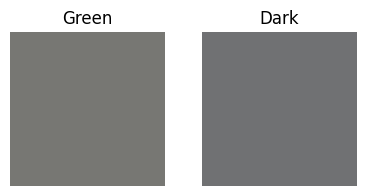

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import math

# Use the extracted r, g, b values to create a 1x1 pixel image array
rgbg_img = np.array([[[rg, gg, bg]]])
rgbd_img = np.array([[[rd, gd, bd]]])

fig, axes = plt.subplots(1,2, figsize=(4, 2)) # Graficar lado a lado

axes[0].imshow(rgbg_img)
axes[0].axis("off")
axes[0].set_title("Green")

axes[1].imshow(rgbd_img)
axes[1].axis("off")
axes[1].set_title("Dark")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from colormath.color_objects import LabColor
# Import the underlying matrix calculation function directly
from colormath.color_diff_matrix import delta_e_cie1976 as _matrix_delta_e_cie1976

# Helper functions to convert LabColor objects to numpy arrays, mirroring
# colormath's internal logic
def _get_lab_color1_vector(color):
    return np.array([color.lab_l, color.lab_a, color.lab_b])

def _get_lab_color2_matrix(color):
    return np.array([[color.lab_l, color.lab_a, color.lab_b]])

# Reference color.
color1 = LabColor(lab_l=50.25248282,lab_a=-0.9271613,lab_b=2.06979034)
# Color to be compared to the reference.
color2 = LabColor(lab_l=47.6887480,lab_a=0.0,lab_b=-1.61764156)

# Prepare inputs for the underlying matrix function
color1_vector = _get_lab_color1_vector(color1)
color2_matrix = _get_lab_color2_matrix(color2)

# Call the core calculation function
delta_e_array = _matrix_delta_e_cie1976(color1_vector, color2_matrix)

# Extract the scalar value using .item(), which is compatible with recent NumPy
delta_e = delta_e_array.item()

print(f"Delta E (CIE1976): {delta_e:.4f}")

Delta E (CIE1976): 4.5858
